# Phase 1 — Data Foundation: EDA (Real Data)

Calls `src/features/load_data.py` for loading + the `DAYS_EMPLOYED` anomaly report, then visualizes the raw Home Credit data directly in this notebook. Read-only against `data/raw/` throughout — no writes happen here.


In [1]:
%run ../src/features/load_data.py

=== Row / column counts ===
application_train        rows=  307,511  cols=122
bureau                   rows=1,716,428  cols= 17
bureau_balance           rows=27,299,925  cols=  3
credit_card_balance      rows=3,840,312  cols= 23
installments_payments    rows=13,605,401  cols=  8
pos_cash_balance         rows=10,001,358  cols=  8
previous_application     rows=1,670,214  cols= 37

=== DAYS_EMPLOYED sentinel-value check (365243) ===
application_train: 55,374 / 307,511 rows (18.01%) have DAYS_EMPLOYED == 365243

=== After handling anomaly ===
is_pensioner_flag set on 55,374 rows
DAYS_EMPLOYED now NaN on 55,374 rows


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tables = load_raw_tables()
app_raw = tables["application_train"].copy()          # before anomaly handling
app = handle_days_employed_anomaly(tables["application_train"])  # after (flag + NaN)
app.shape

(307511, 123)

## Table sizes

How large each of the 7 raw tables is — sets expectations for the Phase 2 SQL pipeline (e.g. `bureau_balance`'s 27M+ rows is why the full pipeline run takes ~25 min).

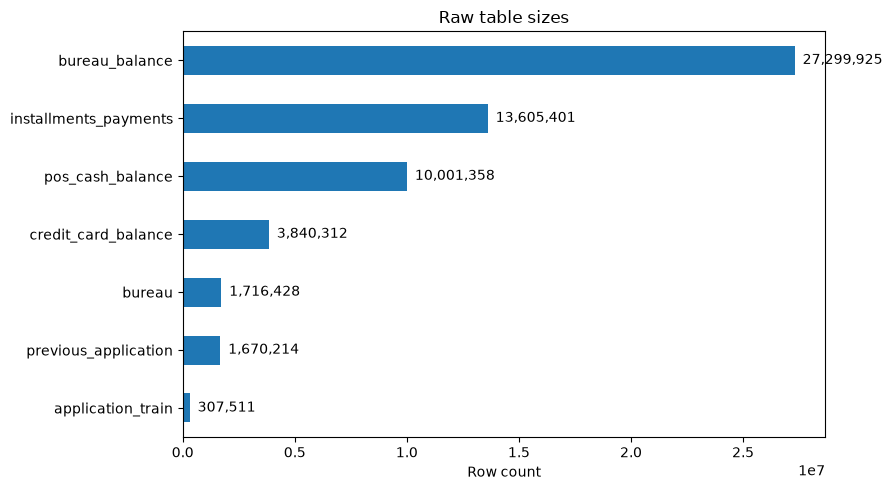

In [3]:
sizes = pd.Series({name: df.shape[0] for name, df in tables.items()}).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
sizes.plot(kind="barh", ax=ax, color="tab:blue")
ax.set_xlabel("Row count")
ax.set_title("Raw table sizes")
for i, v in enumerate(sizes):
    ax.text(v, i, f"  {v:,}", va="center")
plt.tight_layout()
plt.show()

## Target distribution (class imbalance)

`TARGET` (1 = defaulted) — this imbalance is *why* Phase 3 needs SMOTE (split-then-resample) and why raw accuracy/F1 at the default 0.5 threshold would be meaningless.

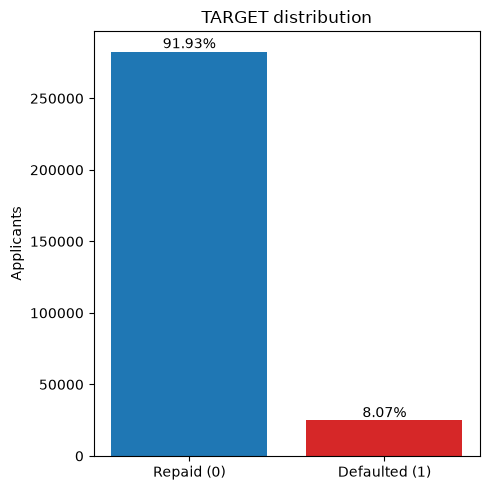

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [4]:
target_counts = app["TARGET"].value_counts().sort_index()
target_pct = 100 * target_counts / target_counts.sum()

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Repaid (0)", "Defaulted (1)"], target_counts.values, color=["tab:blue", "tab:red"])
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%", ha="center", va="bottom")
ax.set_title("TARGET distribution")
ax.set_ylabel("Applicants")
plt.tight_layout()
plt.show()

target_counts

## DAYS_EMPLOYED sentinel anomaly

Before cleaning, `365243` shows up as a spike far to the right of the real distribution (it means "pensioner / not currently employed", not 1000 years of tenure). After `handle_days_employed_anomaly`, that spike is gone and captured instead as `is_pensioner_flag`.

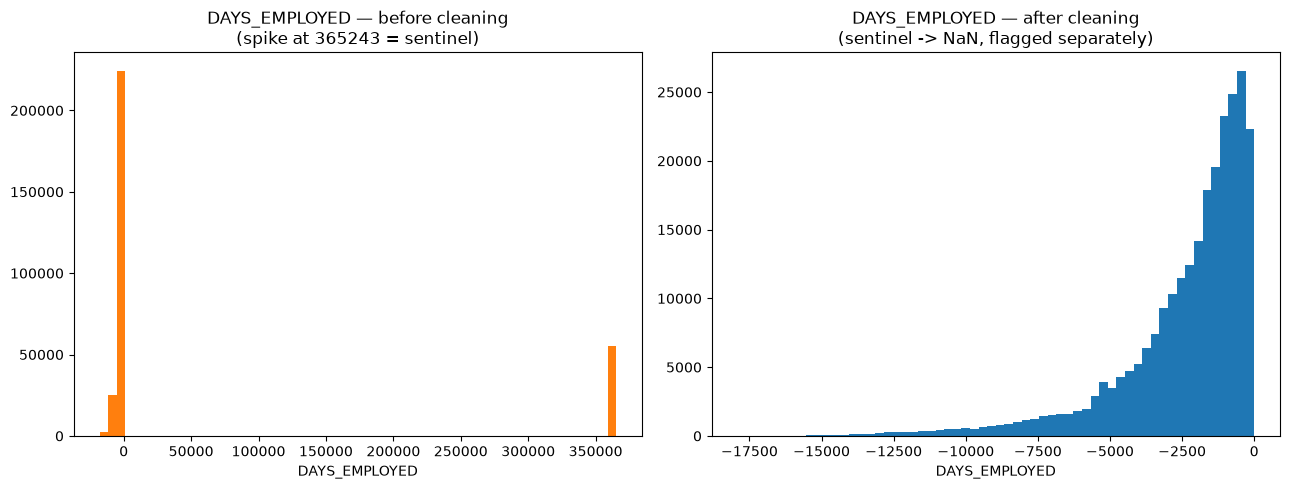

is_pensioner_flag: 55,374 / 307,511 rows (18.01%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(app_raw["DAYS_EMPLOYED"], bins=60, color="tab:orange")
axes[0].set_title("DAYS_EMPLOYED — before cleaning\n(spike at 365243 = sentinel)")
axes[0].set_xlabel("DAYS_EMPLOYED")

axes[1].hist(app["DAYS_EMPLOYED"].dropna(), bins=60, color="tab:blue")
axes[1].set_title("DAYS_EMPLOYED — after cleaning\n(sentinel -> NaN, flagged separately)")
axes[1].set_xlabel("DAYS_EMPLOYED")

plt.tight_layout()
plt.show()

n_flagged = app["is_pensioner_flag"].sum()
print(f"is_pensioner_flag: {n_flagged:,} / {len(app):,} rows ({100*n_flagged/len(app):.2f}%)")

## Missing values overview (application_train)

Which columns need an imputation decision later (resolved in Phase 3: median for numeric, dedicated "missing" category for the 2 text columns).

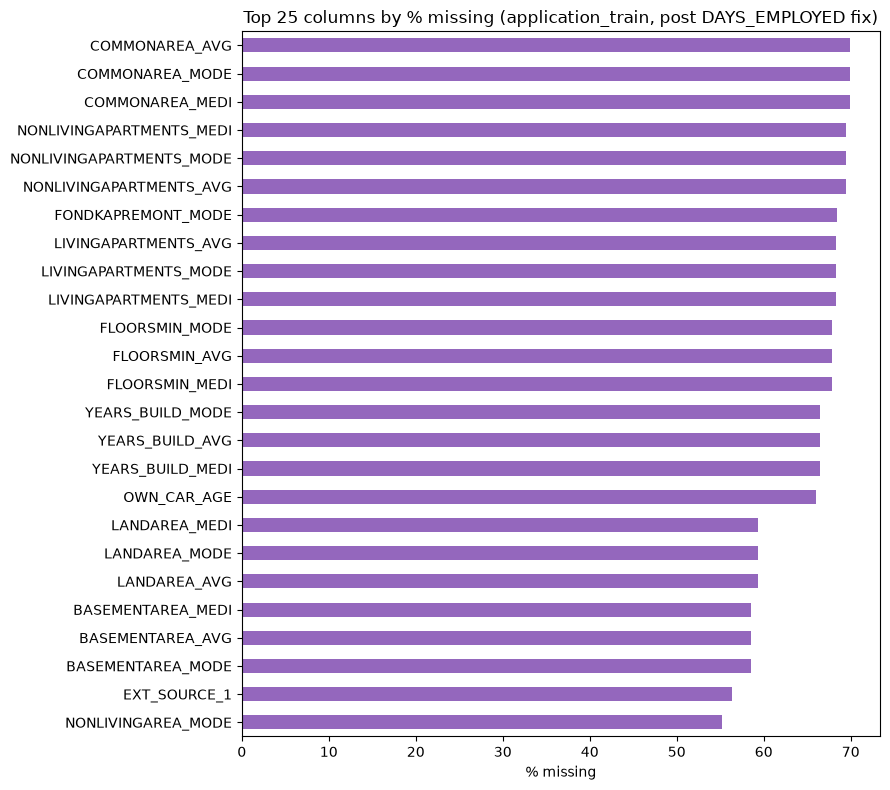

Total columns with any missing values: 68 / 123


In [6]:
missing_pct = (app.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(25)

fig, ax = plt.subplots(figsize=(9, 8))
top_missing.sort_values().plot(kind="barh", ax=ax, color="tab:purple")
ax.set_xlabel("% missing")
ax.set_title("Top 25 columns by % missing (application_train, post DAYS_EMPLOYED fix)")
plt.tight_layout()
plt.show()

print(f"Total columns with any missing values: {(missing_pct > 0).sum()} / {app.shape[1]}")

## Key numeric feature distributions

`EXT_SOURCE_1/2/3` (external bureau scores) and `AMT_INCOME_TOTAL` are the exact 4 features the Phase 1 synthetic overlay drifts — worth knowing their real-data shape before seeing them get reweighted later.

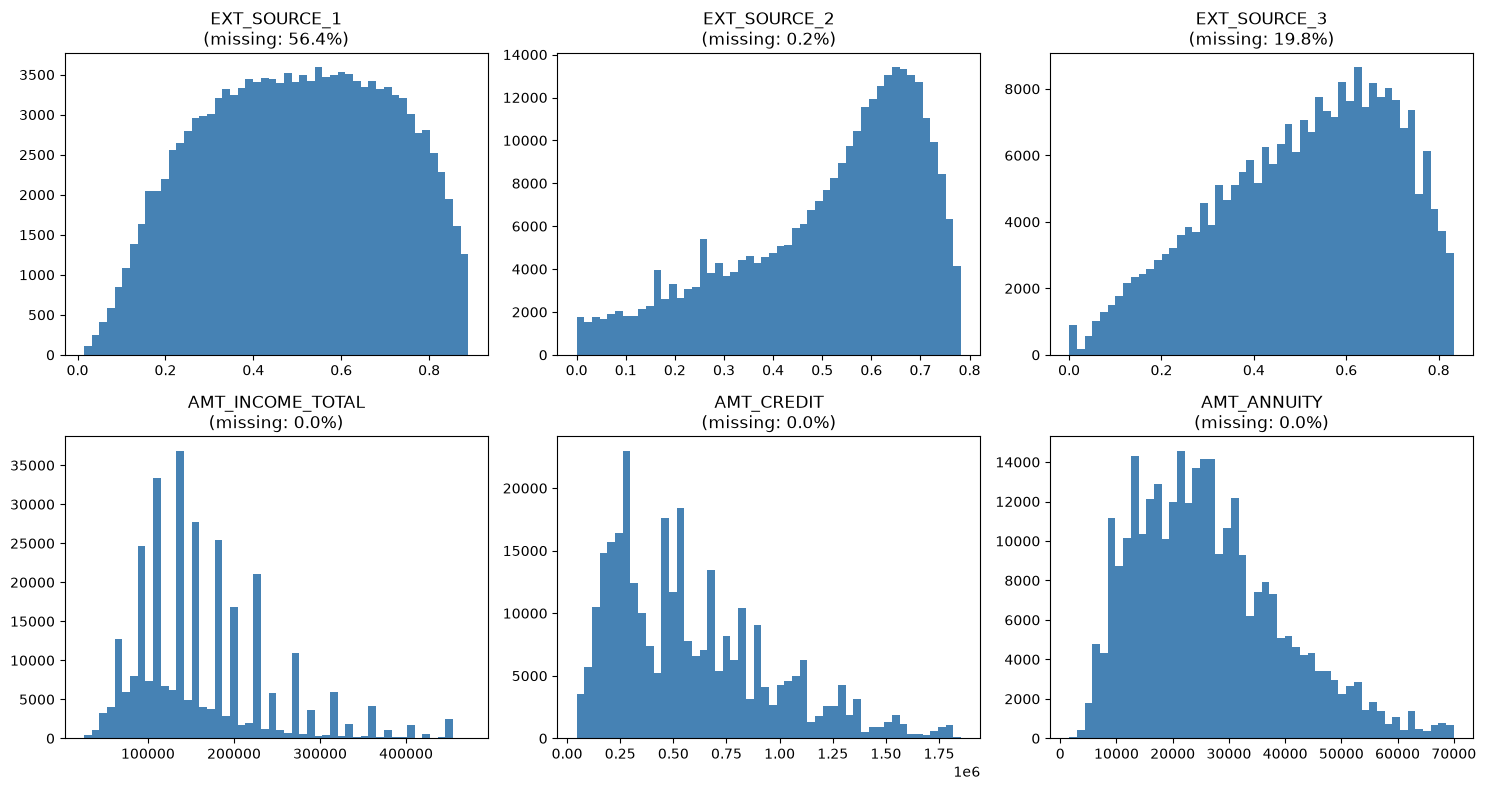

In [12]:
numeric_cols = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_cols):
    data = app[col].dropna()
    upper = data.quantile(0.99)  # clip top 1% for readability
    ax.hist(data[data <= upper], bins=50, color="steelblue")
    ax.set_title(f"{col}\n(missing: {100 * app[col].isna().mean():.1f}%)")

plt.tight_layout()
plt.show()

## EXT_SOURCE vs TARGET

These external scores are among the most predictive features in the dataset — visible here as a real separation in distribution between repaid vs. defaulted.

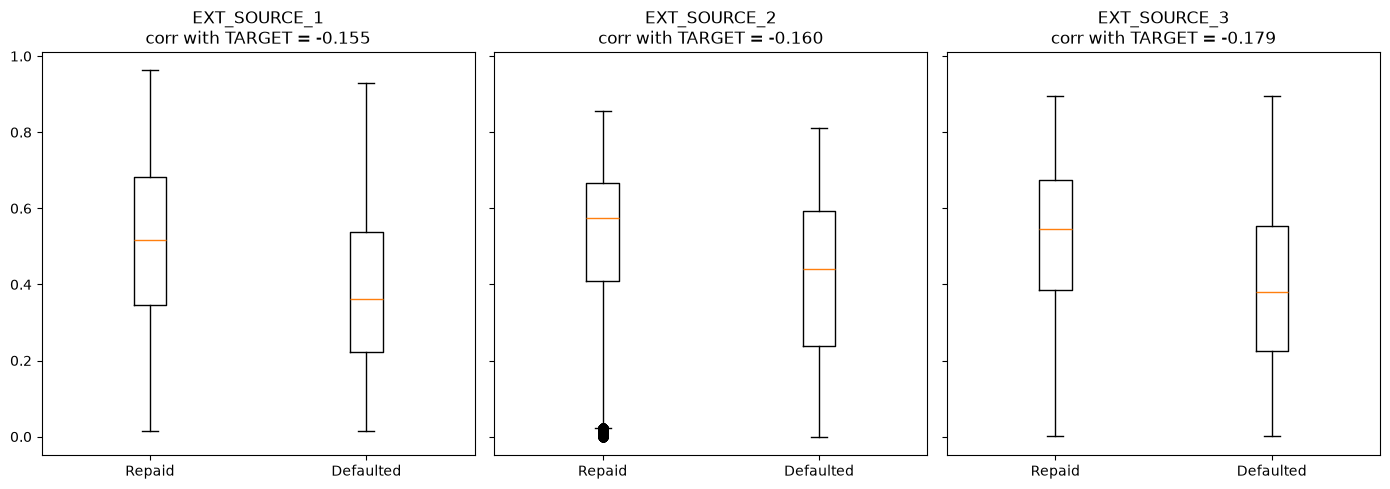

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    data0 = app.loc[app["TARGET"] == 0, col].dropna()
    data1 = app.loc[app["TARGET"] == 1, col].dropna()
    ax.boxplot([data0, data1], tick_labels=["Repaid", "Defaulted"])
    corr = app[[col, "TARGET"]].dropna().corr().iloc[0, 1]
    ax.set_title(f"{col}\ncorr with TARGET = {corr:.3f}")
plt.tight_layout()
plt.show()

## Demographic breakdown (fairness-relevant attributes)

Default rate by `CODE_GENDER`, `NAME_FAMILY_STATUS`, and `age_band` — the same 3 attributes and the same age-band bins (`[18,25,35,45,55,65,100]`) used later in `src/fairness/fairness_metrics.py`, so this view stays directly comparable to the Phase 4 fairness results.

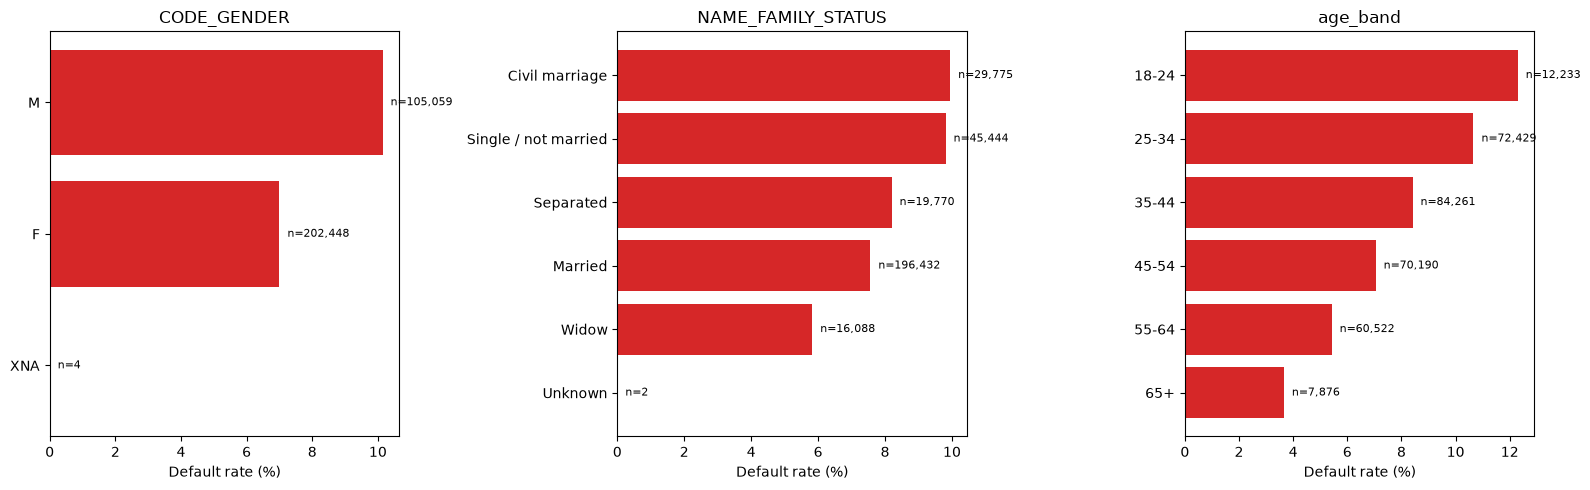

In [15]:
AGE_BAND_EDGES = [18, 25, 35, 45, 55, 65, 100]
AGE_BAND_LABELS = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

app["age_years"] = -app["DAYS_BIRTH"] / 365.25
app["age_band"] = pd.cut(app["age_years"], bins=AGE_BAND_EDGES, labels=AGE_BAND_LABELS, right=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, group_col in zip(axes, ["CODE_GENDER", "NAME_FAMILY_STATUS", "age_band"]):
    rates = app.groupby(group_col, observed=True)["TARGET"].agg(["mean", "count"])
    rates = rates.sort_values("mean")
    ax.barh(rates.index.astype(str), rates["mean"] * 100, color="tab:red")
    ax.set_xlabel("Default rate (%)")
    ax.set_title(group_col)
    for i, (rate, n) in enumerate(zip(rates["mean"], rates["count"])):
        ax.text(rate * 100, i, f"  n={n:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Notes / what to take away

- `CODE_GENDER` has a tiny `XNA` category (4 rows) — matches the bug found and fixed in Phase 4's fairness metrics (tiny subgroups were corrupting the max-min spread before being excluded).
- The real gender default-rate gap here is the pre-injection baseline — compare against `data/synthetic/README.md`'s P0 gap (-0.0315) once you look at the synthetic overlay.
- This notebook only covers `application_train`. Bureau/previous-application/installments/POS/credit-card tables are aggregated up to `SK_ID_CURR` in Phase 2's SQL pipeline, not explored row-level here.